Data Visualization

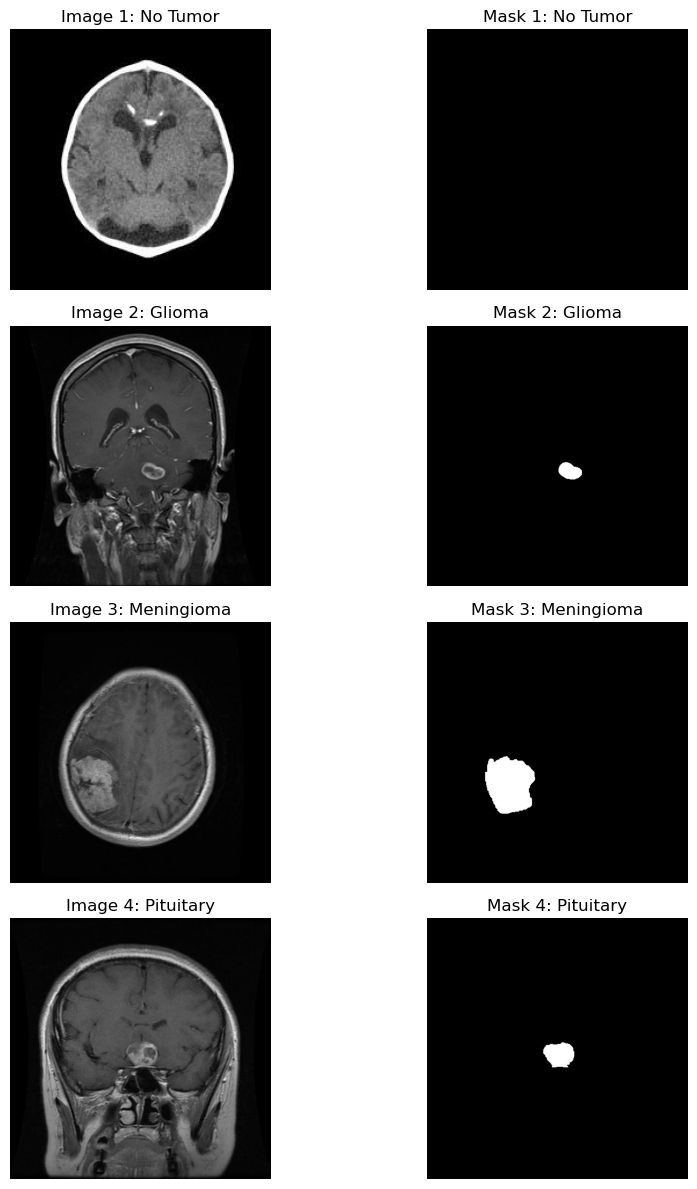

In [2]:
import cv2
import matplotlib.pyplot as plt


def load_image(path):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Unable to load image at {path}")
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  


paths = [
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\0\Tr-no_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\0\Tr-no_0010_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\1\Tr-gl_0014.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\1\Tr-gl_0014_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\2\Tr-me_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\2\Tr-me_0010_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\3\Tr-pi_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\3\Tr-pi_0010_m.jpg"
]


images = [load_image(path) for path in paths]


titles = [
    "Image 1: No Tumor", "Mask 1: No Tumor",
    "Image 2: Glioma", "Mask 2: Glioma",
    "Image 3: Meningioma", "Mask 3: Meningioma",
    "Image 4: Pituitary", "Mask 4: Pituitary"
]


fig, axs = plt.subplots(4, 2, figsize=(10, 12))


for i, ax in enumerate(axs.flat):
    if images[i] is not None:
        ax.imshow(images[i])
    else:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center', fontsize=12, color='red')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()


Data Preprocessing

In [3]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from albumentations import HorizontalFlip, VerticalFlip, Rotate, Compose


DATASET_PATH = r"D:\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask):
    transform = Compose([
        HorizontalFlip(p=1),
        VerticalFlip(p=1),
        Rotate(limit=45, p=1)
    ])
    augmented = transform(image=image, mask=mask)
    return augmented["image"], augmented["mask"]

def load_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []

    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, "image", str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))
        
        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue
                
                image = cv2.resize(image, target_size)
                image = image / 255.0  

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0  

                    # Add  image and mask
                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)
                    #  augmentation and add augmented images and masks
                    aug_image, aug_mask = augment_data(image, mask)
                    images.append(aug_image)
                    masks.append(aug_mask)
                    labels.append(class_index)
                    
                    
                    
    images = np.array(images, dtype=np.float32).reshape(-1, 128, 128, 1)
    masks = np.array(masks, dtype=np.float32).reshape(-1, 128, 128, 1)
    labels = np.array(labels, dtype=np.int32)

    return images, masks, labels

def split_data(images, masks, labels, test_size=0.2):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )
    return Img_train, Img_test, label_train, label_test, mask_train, mask_test


if __name__ == "__main__":
    
    images, masks, labels = load_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"Number of images: {images.shape[0]}, Number of masks: {masks.shape[0]}, Number of labels: {labels.shape[0]}")
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = split_data(images, masks, labels, test_size=0.2)
    
    print(f"Training data: {Img_train.shape[0]} | Test data: {Img_test.shape[0]}")



d:\anaconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Loading pituitary_tumor: 100%|██████████| 994/994 [00:11<00:00, 82.90it/s] 


Number of images: 8474, Number of masks: 8474, Number of labels: 8474
Training data: 6779 | Test data: 1695


Create Model U-net

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, BatchNormalization, Dropout)


def unet_model(input_size=(128, 128, 1)):
    inputs = Input(input_size)

    # Encoder(Down Sampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.2)(p1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.2)(p2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.3)(p3)

    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.3)(c4)

    # Decoder(Up Sampling)
    u5 = Conv2DTranspose(256, (2, 2), strides=(2,2), padding='same')(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)
    c5 = BatchNormalization()(c5)

    u6 = Conv2DTranspose(128, (2, 2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)
    c6 = BatchNormalization()(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)
    c7 = BatchNormalization()(c7)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    return model


In [5]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def dice_loss(mask_true, mask_pred, smooth=1e-6):
    mask_true_f = tf.keras.backend.flatten(mask_true)
    mask_pred_f = tf.keras.backend.flatten(mask_pred)
     
    intersection = tf.keras.backend.sum(mask_true_f * mask_pred_f)

    return 1 - ((2. * intersection + smooth) / 
                (tf.keras.backend.sum(mask_true_f) + tf.keras.backend.sum(mask_pred_f) + smooth))

model = unet_model()
model.compile(optimizer=Adam(learning_rate=0.001), loss=dice_loss, metrics=["accuracy"])
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]  

 Total params: 7,707,457 (29.40 MB)

 Trainable params: 7,701,825 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

Train Model

In [ ]:



history = model.fit(
    Img_train, mask_train,
    validation_split=0.2,
    epochs=25,  
    batch_size=8,  
    verbose=1
)


model.save("model.h5")
print("Model Saved 100%")





Epoch 1/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2298s 3s/step - accuracy: 0.8848 - loss: 0.7624 - val_accuracy: 0.9710 - val_loss: 0.7505
Epoch 2/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2275s 3s/step - accuracy: 0.9899 - loss: 0.4092 - val_accuracy: 0.9903 - val_loss: 0.3893
Epoch 3/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2348s 3s/step - accuracy: 0.9911 - loss: 0.3298 - val_accuracy: 0.9908 - val_loss: 0.3452
Epoch 4/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 5690s 7s/step - accuracy: 0.9916 - loss: 0.2941 - val_accuracy: 0.9903 - val_loss: 0.4106
Epoch 5/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 26661s 31s/step - accuracy: 0.9922 - loss: 0.2505 - val_accuracy: 0.9915 - val_loss: 0.2647
Epoch 6/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2207s 3s/step - accuracy: 0.9926 - loss: 0.2389 - val_accuracy: 0.9926 - val_loss: 0.2071
Epoch 7/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2206s 3s/step - accuracy: 0.9927 - loss: 0.2167 - val_accuracy: 0.9921 - val_loss: 0.2271
Epoch 8/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2211s 3s/step - accuracy: 0.9930 - loss: 0.2108 

Model Saved 100%


Test Model

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, Img_test, mask_test, num_samples=5):
  
    indices = np.random.choice(len(Img_test), num_samples, replace=False)  

    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_mask = mask_test[idx]

        
        test_image_input = np.expand_dims(test_image, axis=0)

        
        pred_mask = model.predict(test_image_input)[0]  

        
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

model = unet_model(input_size=(128, 128, 1))


model.load_weights(r"C:\Users\MSI GAMER\Downloads\model.h5")


model.compile(optimizer=Adam(), loss=dice_loss, metrics=['accuracy'])

test_model(model, Img_test, mask_test, num_samples=5)


NameError: name 'unet_model' is not defined

In [12]:
from tensorflow.keras.optimizers import Adam



model = unet_model(input_size=(128, 128, 1))


model.load_weights(r"C:\Users\MSI GAMER\Downloads\model.h5")


model.compile(optimizer=Adam(), loss=dice_loss, metrics=['accuracy'])


test_loss, test_accuracy = model.evaluate(Img_test, mask_test, batch_size=16)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


106/106 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9930 - loss: 0.1762
Test Accuracy: 0.9927
Test Loss: 0.1875
